In [1]:
import os, sys
print(os.getcwd())
print(sys.executable)

C:\Users\Admin\heart-disease-mlops\notebooks
C:\Users\Admin\heart-disease-mlops\venv\Scripts\python.exe


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
FIG_DIR = Path("../screenshots/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/heart_clean.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [5]:
print(df.shape)
df.info()
df.describe().T

(303, 14)
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


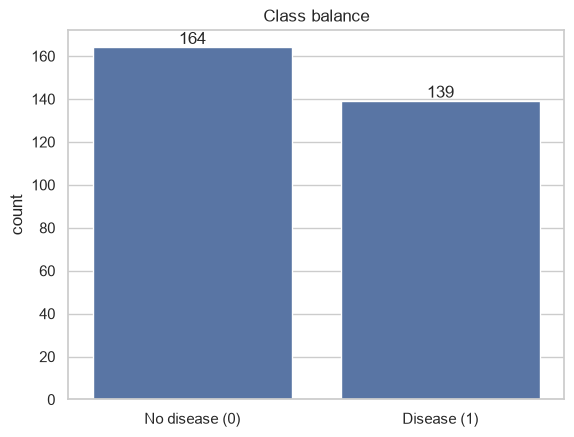

In [7]:
labels = df["target"].map({0: "No disease (0)", 1: "Disease (1)"})
ax = sns.countplot(x=labels, order=["No disease (0)", "Disease (1)"])
ax.set_title("Class balance")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.savefig(FIG_DIR / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

Observation:The classes are nearly balanced (about 54% vs 46%), so accuracy is a fair metric here and no resampling is needed

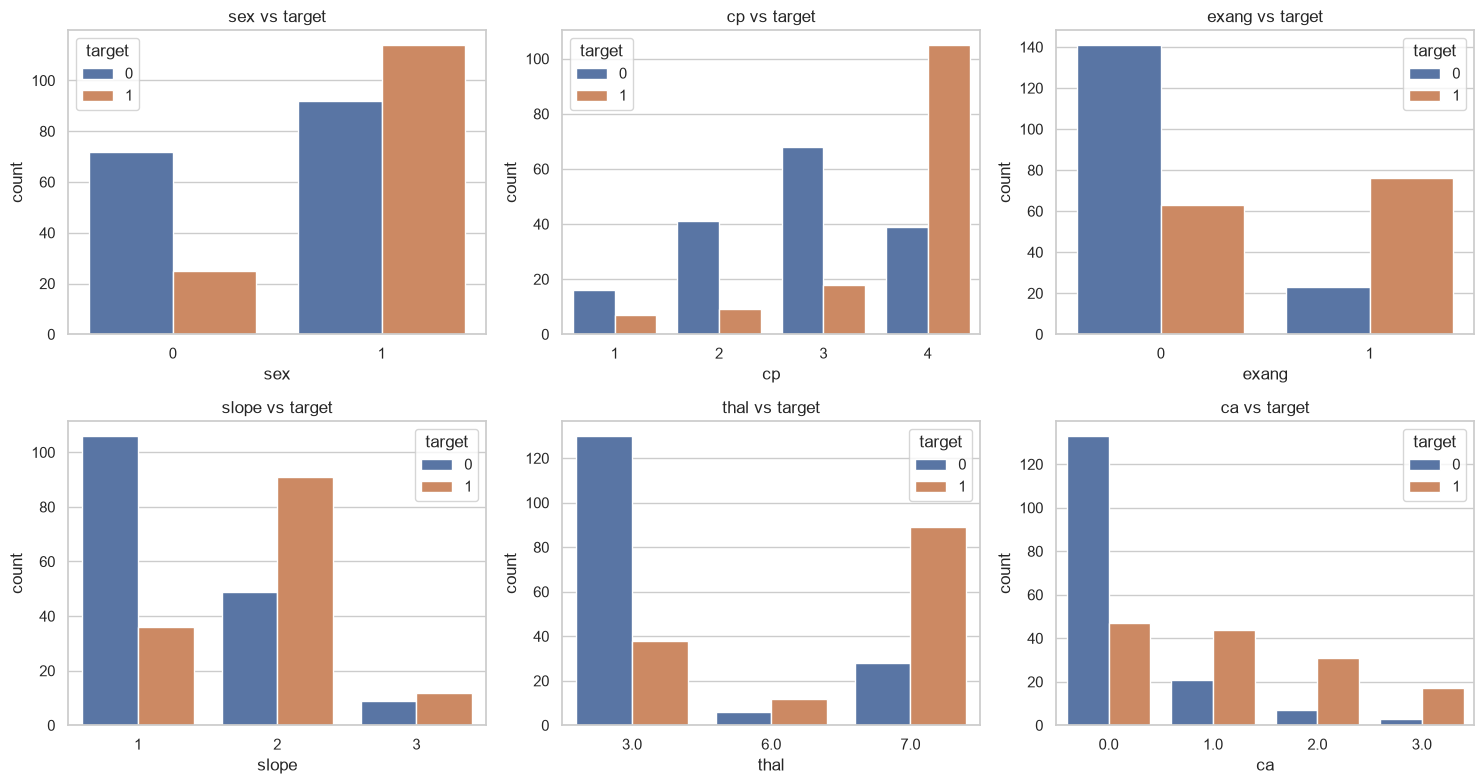

In [8]:
cat_cols = ["sex", "cp", "exang", "slope", "thal", "ca"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cat_cols):
    sns.countplot(data=df, x=col, hue="target", ax=ax)
    ax.set_title(f"{col} vs target")
plt.tight_layout()
plt.savefig(FIG_DIR / "categorical_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()

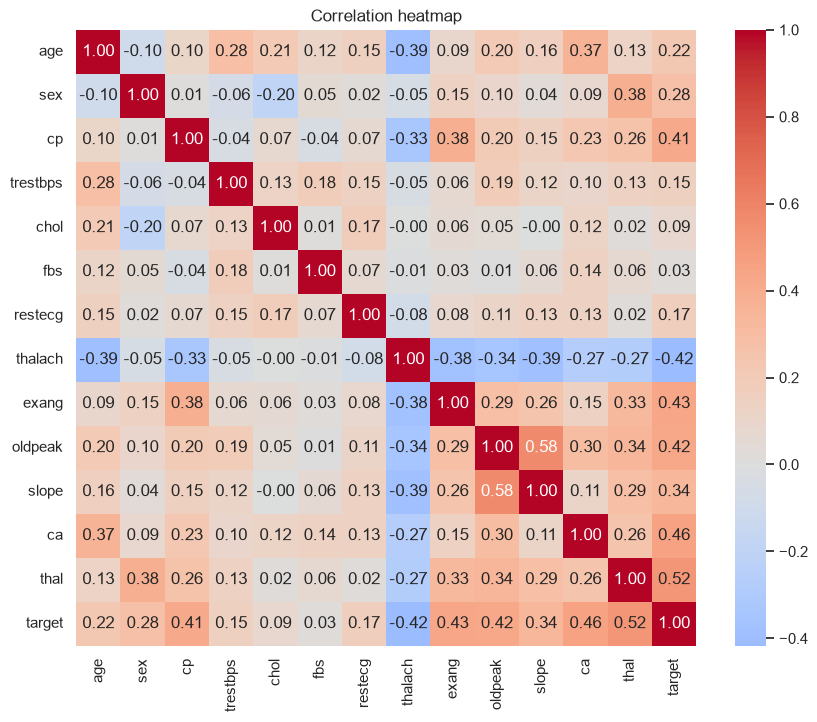

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

No pair is above about 0.6, so you don't need to drop features.
Pearson correlation on categorical columns like cp, thal and slope is only a rough guide. These are coded categories, so you can mention that you'll one-hot encode them in the modelling step.
Weak correlation doesn't mean useless. chol may still help in combination with other features, so a Random Forest's feature importances are a good cross-check later.

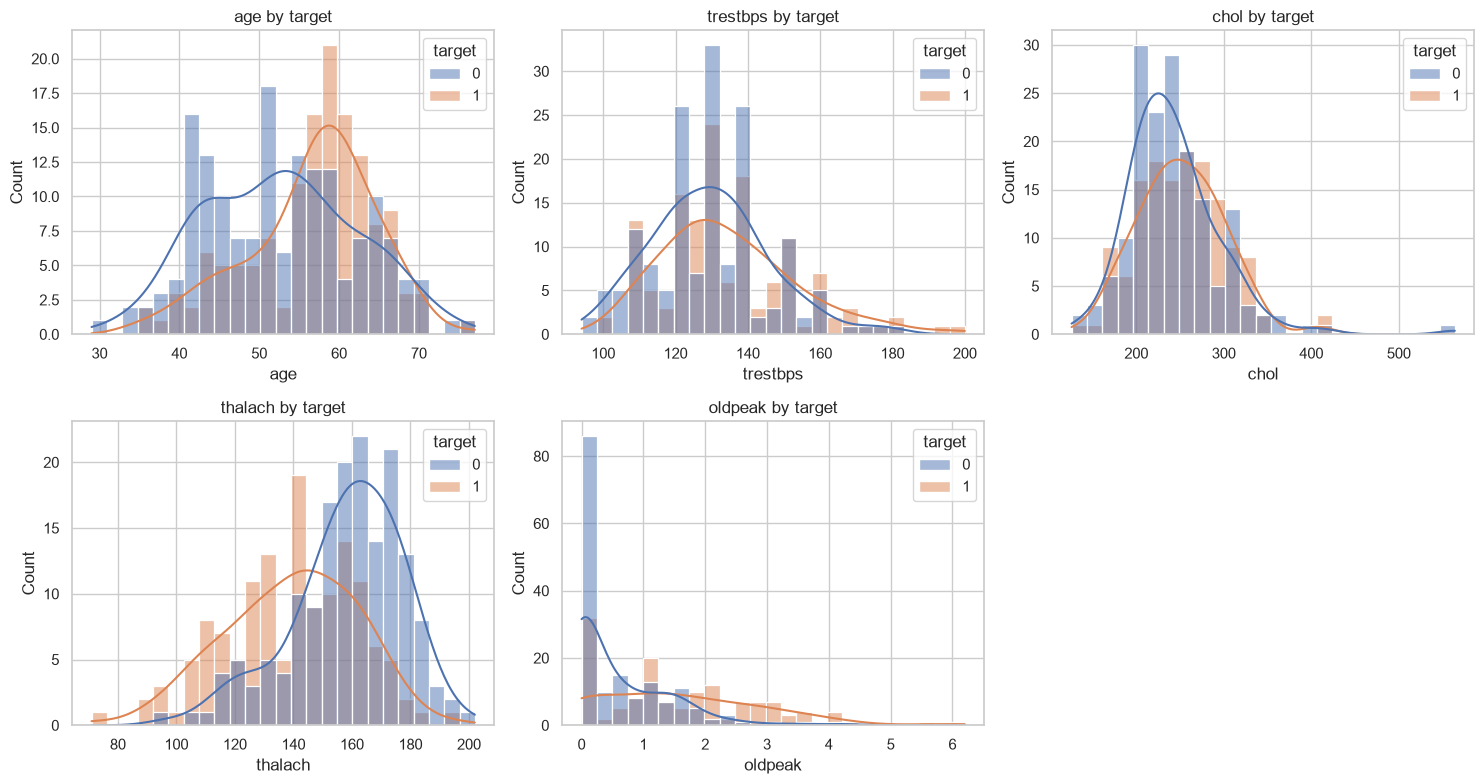

In [10]:
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=df, x=col, hue="target", kde=True, ax=ax, bins=25)
    ax.set_title(f"{col} by target")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "numeric_histograms.png", dpi=150, bbox_inches="tight")
plt.show()